Powerlifting Cohort Shift - Top Lifters by IPF GL

William Le - 06/07/2026

Notebook 1 looked at the top 50 each year. This one zooms in on the top 20 (the tier where Worlds qualification actually happens) and looks at the all-time leaderboard to see who actually owns the top spots in raw tested IPF powerlifting history.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from powerlifting_cohort.features import add_features, dedupe_lifter_meets

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_pickle("../data/processed/openipf_scoped.pkl")
df = add_features(df)
df = df[df["is_ipf_class"]]
df = dedupe_lifter_meets(df)

print(f"{len(df):,} lifter-meets, {df['Name'].nunique():,} lifters")

539,432 lifter-meets, 212,346 lifters


All-time top 20 IPF GL performances by sex - one row per lifter-meet, no per-lifter dedupe so multiple meets from the same person can show up.

In [3]:
def top_n_alltime(df, sex, n=20):
  sub = df[df["Sex"] == sex].dropna(subset=["Goodlift"]).copy()
  idx = sub.groupby("Name")["Goodlift"].idxmax()
  best_per_lifter = sub.loc[idx]
  return (best_per_lifter
          .nlargest(n, "Goodlift")
          [["Date", "Age", "Name", "WeightClassKg", "TotalKg", "Goodlift", "MeetName"]])

print("Men:")
print(top_n_alltime(df, "M").to_string(index=False))
print()
print("Women:")
print(top_n_alltime(df, "F").to_string(index=False))

Men:
      Date  Age                   Name WeightClassKg  TotalKg  Goodlift                                        MeetName
2026-01-31 26.0      Austin Perkins #1            74    891.5    131.45            Sheffield Powerlifting Championships
2026-03-05 19.0          Elliott Sykes            74    852.5    125.61                                  Open Nationals
2025-10-11 22.0      Joseph Borenstein            83    904.0    125.18                       Avancus Houston Primetime
2021-06-14 32.5          Taylor Atwood            74    838.5    123.42                                   Raw Nationals
2026-03-05 20.0        William Ball #2            93    930.0    122.36                                  Open Nationals
2026-01-31  NaN   Kjell Egil Bakkelund            66    782.0    122.25            Sheffield Powerlifting Championships
2025-11-22 28.0          Bobb Matthews           120   1010.5    121.74                                      SBD Austin
2025-04-03 25.0     Anthony McNaugh

How many of the all-time top 20 entries are from the past 2 years?

In [4]:
for sex in ["M", "F"]:
  top = top_n_alltime(df, sex)
  recent = top[top["Date"] >= "2024-01-01"]
  jr_age = top[top["Age"] < 24]
  print(f"{sex}: {len(recent)}/20 from 2024+, {len(jr_age)}/20 by lifters under 24")

M: 18/20 from 2024+, 6/20 by lifters under 24
F: 20/20 from 2024+, 2/20 by lifters under 24


Per-year top 20 by IPF GL. Each lifter contributes their best meet of the year. Median age and youngest age in the top 20 by year and sex.

In [5]:
ly = df.dropna(subset=["Goodlift", "Age"]).copy()
idx = ly.groupby(["Name", "Year", "Sex"])["Goodlift"].idxmax()
ly = ly.loc[idx, ["Name", "Year", "Sex", "Goodlift", "Age", "age_category"]].reset_index(drop=True)

def top20_summary(ly, sex):
  sub = ly[ly["Sex"] == sex]
  rows = []
  for yr, grp in sub.groupby("Year"):
    if len(grp) < 20: continue
    top = grp.nlargest(20, "Goodlift")
    rows.append({
        "Year": int(yr),
        "median_age": top["Age"].median(),
        "youngest": top["Age"].min(),
        "jr_count": (top["age_category"] == "Junior").sum(),
        "sj_count": (top["age_category"] == "SubJunior").sum(),
        "top_gl": top["Goodlift"].max()
    })
  return pd.DataFrame(rows)

sm = top20_summary(ly, "M").query("2014 <= Year <= 2025")
sf = top20_summary(ly, "F").query("2014 <= Year <= 2025")

print("Men:")
print(sm.to_string(index=False))
print()
print("Women:")
print(sf.to_string(index=False))

Men:
 Year  median_age  youngest  jr_count  sj_count  top_gl
 2014       27.00      18.5         5         1  111.31
 2015       31.50      18.5         2         1  111.37
 2016       29.50      19.0         4         0  114.17
 2017       28.50      20.0         5         0  113.98
 2018       26.75      21.0         7         0  115.23
 2019       24.25      20.0         9         0  116.89
 2020       24.75      21.0         6         0  120.97
 2021       26.25      21.5         2         0  123.42
 2022       26.25      22.0         3         0  116.35
 2023       26.75      22.0         1         0  117.74
 2024       27.75      21.0         1         0  123.83
 2025       28.00      19.0         5         0  126.32

Women:
 Year  median_age  youngest  jr_count  sj_count  top_gl
 2014       32.50      22.0         2         0  107.80
 2015       33.75      22.5         2         0  114.02
 2016       30.00      16.5         2         1  108.96
 2017       28.75      21.5        

Median age and youngest age of the top 20 each year.

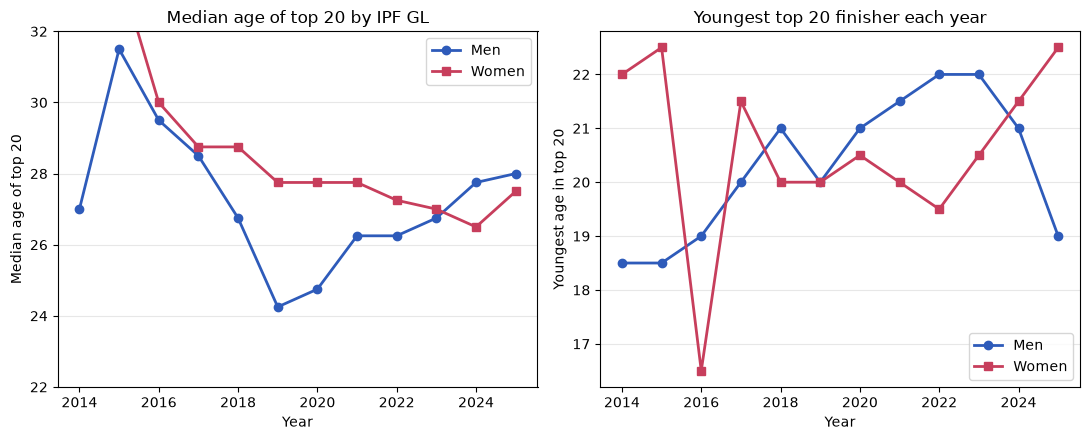

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(sm["Year"], sm["median_age"], "o-", color="#2E5BBA", linewidth=2, label="Men")
ax1.plot(sf["Year"], sf["median_age"], "s-", color="#C73E5C", linewidth=2, label="Women")
ax1.set_xlabel("Year")
ax1.set_ylabel("Median age of top 20")
ax1.set_title("Median age of top 20 by IPF GL")
ax1.set_ylim(22, 32)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.plot(sm["Year"], sm["youngest"], "o-", color="#2E5BBA", linewidth=2, label="Men")
ax2.plot(sf["Year"], sf["youngest"], "s-", color="#C73E5C", linewidth=2, label="Women")
ax2.set_xlabel("Year")
ax2.set_ylabel("Youngest age in top 20")
ax2.set_title("Youngest top 20 finisher each year")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/03_top20.png", dpi=150, bbox_inches="tight")
plt.show()

Junior-age and Sub-Junior-age lifters who have cracked the all-time top 50 IPF GL. This is where Perkins, Sitko, Borenstein, Sykes, Ball, Chapon, Jacob, and others show up as a single cohort.

In [7]:
def jr_in_alltime(df, sex, n=50):
  top = (df[df["Sex"] == sex]
         .dropna(subset=["Goodlift", "Age"])
         .nlargest(n, "Goodlift"))
  return top[top["Age"] < 24][["Date", "Age", "Name", "WeightClassKg", "TotalKg", "Goodlift", "MeetName"]]

print("Men under 24 in all-time top 50:")
print(jr_in_alltime(df, "M").to_string(index=False))
print()
print("Women under 24 in all-time top 50:")
print(jr_in_alltime(df, "F").to_string(index=False))

Men under 24 in all-time top 50:
      Date  Age              Name WeightClassKg  TotalKg  Goodlift                                                MeetName
2026-03-05 19.0     Elliott Sykes            74    852.5    125.61                                          Open Nationals
2025-10-11 22.0 Joseph Borenstein            83    904.0    125.18                               Avancus Houston Primetime
2025-04-03 22.0 Joseph Borenstein            83    900.0    124.65                                  Classic Open Nationals
2026-03-05 23.0 Joseph Borenstein            83    892.5    123.98                                          Open Nationals
2025-06-08 22.0 Joseph Borenstein            83    890.0    123.32                World Classic Powerlifting Championships
2026-03-05 20.0   William Ball #2            93    930.0    122.36                                          Open Nationals
2020-11-14 23.0     Ashton Rouska           105    950.5    120.97                                 Virgini

The all-time top 20 is dominated by recent meets and by lifters under 24 - 9 of the men's top 20 are by lifters under 24, and almost the entire top 20 is from 2024-2026. Sykes at 19 currently holds the #1 all-time GL on the men's side. Borenstein has 3 of the top 8 entries, all under age 23. The women's list is less dominated by junior-age lifters but Sitko's 133.37 at age 22.5 is the all-time #1 by a wide margin. The names list at the end shows the cohort the writeup is about, identified directly from the all-time leaderboard rather than per-meet wins.